# Proyek Klasifikasi Gambar: [Natural Images]
- **Nama:** Irma Dwiyanti
- **Email:** mc222d5x1689@student.devacademy.id
- **ID Dicoding:** MC222D5X1689



## Import Semua Packages/Library yang Digunakan

In [2]:
!pip install tensorflowjs packaging>=24.2.0

In [3]:
import ydf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import zipfile
import shutil
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

# Import Callback
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Untuk mengkonversi model ke TFLite dan TFJS
import tensorflowjs as tfjs
import pathlib

# Google Colab
from google.colab import drive

## Data Preparation

### Data Loading

In [4]:
# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
# Menentukan path dataset
dataset_path = "/content/drive/MyDrive/Colab Notebooks/Klasifikasi Gambar/natural.zip"
extract_to = "/content/fruits"

In [6]:
# Mengecek apakah file zip ada sebelum ekstraksi
if os.path.exists(dataset_path):
    # Ekstraksi dataset
    with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Dataset berhasil diekstrak ke {extract_to}")
else:
    print(f"File {dataset_path} tidak ditemukan!")

Dataset berhasil diekstrak ke /content/fruits


In [7]:
# Melihat isi folder dataset
lokasi_dataset = os.path.join(extract_to, "natural_images")
print("Folder yang ada di dalam dataset:", os.listdir(lokasi_dataset))

# Menghitung total jumlah gambar di setiap subfolder (misalnya, setiap folder adalah label)
total_dataset = 0
for label in os.listdir(lokasi_dataset):
    label_path = os.path.join(lokasi_dataset, label)
    if os.path.isdir(label_path):  # Pastikan hanya folder yang dihitung
        total_dataset += len(os.listdir(label_path))

print(f"\nTotal dataset: {total_dataset}")

Folder yang ada di dalam dataset: ['flower', 'person', 'car', 'airplane', 'cat', 'motorbike', 'dog', 'fruit']

Total dataset: 6899


### Data Preprocessing

#### Split Dataset

In [8]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Definisikan path dataset
dataset_dir = "/content/fruits/natural_images"
train_dir = "/content/fruits/train"
val_dir = "/content/fruits/val"
test_dir = "/content/fruits/test"

# Membuat folder jika belum ada
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Daftar semua subfolder di dalam dataset (kelas)
classes = os.listdir(dataset_dir)

# Membuat subfolder di dalam train, val, test untuk setiap kelas
for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

# Membagi dataset menjadi train (60%), val (20%), dan test (20%)
for cls in classes:
    cls_folder = os.path.join(dataset_dir, cls)

    # Hanya lanjutkan jika folder kelas memiliki gambar
    if len(os.listdir(cls_folder)) > 0:
        images = os.listdir(cls_folder)

        # Split data
        train_images, temp_images = train_test_split(images, test_size=0.4, random_state=42)
        val_images, test_images = train_test_split(temp_images, test_size=0.5, random_state=42)

        # Pindahkan gambar ke folder yang sesuai
        for image in train_images:
            shutil.copy(os.path.join(cls_folder, image), os.path.join(train_dir, cls, image))
        for image in val_images:
            shutil.copy(os.path.join(cls_folder, image), os.path.join(val_dir, cls, image))
        for image in test_images:
            shutil.copy(os.path.join(cls_folder, image), os.path.join(test_dir, cls, image))

print("Dataset telah dibagi menjadi train, val, dan test.")


Dataset telah dibagi menjadi train, val, dan test.


In [9]:
# Definisikan folder train, val, test
folder_train = "/content/fruits/train"
folder_val = "/content/fruits/val"
folder_test = "/content/fruits/test"

# Fungsi untuk menghitung jumlah gambar dan kelas di folder
def count_images_in_folder(folder_path):
    total_images = 0
    classes = os.listdir(folder_path)
    for cls in classes:
        cls_folder = os.path.join(folder_path, cls)
        if os.path.isdir(cls_folder):
            total_images += len(os.listdir(cls_folder))
    return total_images, classes

# Hitung jumlah gambar dan kelas untuk train, val, dan test
train_images_count, train_classes = count_images_in_folder(folder_train)
val_images_count, val_classes = count_images_in_folder(folder_val)
test_images_count, test_classes = count_images_in_folder(folder_test)

# Tampilkan jumlah gambar dan kelas di masing-masing folder
print(f"Jumlah gambar di folder train: {train_images_count}")
print(f"Jumlah kelas di folder train: {len(train_classes)}")
print(f"Kelas di folder train: {train_classes}")

print(f"\nJumlah gambar di folder val: {val_images_count}")
print(f"Jumlah kelas di folder val: {len(val_classes)}")
print(f"Kelas di folder val: {val_classes}")

print(f"\nJumlah gambar di folder test: {test_images_count}")
print(f"Jumlah kelas di folder test: {len(test_classes)}")
print(f"Kelas di folder test: {test_classes}")

Jumlah gambar di folder train: 4136
Jumlah kelas di folder train: 8
Kelas di folder train: ['flower', 'person', 'car', 'airplane', 'cat', 'motorbike', 'dog', 'fruit']

Jumlah gambar di folder val: 1380
Jumlah kelas di folder val: 8
Kelas di folder val: ['flower', 'person', 'car', 'airplane', 'cat', 'motorbike', 'dog', 'fruit']

Jumlah gambar di folder test: 1383
Jumlah kelas di folder test: 8
Kelas di folder test: ['flower', 'person', 'car', 'airplane', 'cat', 'motorbike', 'dog', 'fruit']


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Definisikan path ke folder train, val, dan test
folder_train = "/content/fruits/train"
folder_val = "/content/fruits/val"
folder_test = "/content/fruits/test"

# Ukuran gambar dan batch
ukuran_gambar = (150, 150)
jumlah_batch = 32

# Generator untuk data latih dengan augmentasi
augmentasi_latih = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

# Generator untuk validasi dan pengujian (tanpa augmentasi)
augmentasi_validasi = ImageDataGenerator(rescale=1.0/255)

# Aliran data dari folder masing-masing
generator_latih = augmentasi_latih.flow_from_directory(
    folder_train,
    target_size=ukuran_gambar,
    batch_size=jumlah_batch,
    class_mode='categorical'
)

generator_validasi = augmentasi_validasi.flow_from_directory(
    folder_val,
    target_size=ukuran_gambar,
    batch_size=jumlah_batch,
    class_mode='categorical'
)

generator_uji = augmentasi_validasi.flow_from_directory(
    folder_test,
    target_size=ukuran_gambar,
    batch_size=jumlah_batch,
    class_mode='categorical',
    shuffle=False
)


Found 4136 images belonging to 8 classes.
Found 1380 images belonging to 8 classes.
Found 1383 images belonging to 8 classes.


## Modelling

In [11]:
from tensorflow.keras import layers, models

# Membangun model CNN
model = models.Sequential()

# Lapisan konvolusi pertama
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Lapisan konvolusi kedua
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Lapisan konvolusi ketiga
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Lapisan konvolusi keempat
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten untuk mengubah data 2D menjadi 1D
model.add(layers.Flatten())

# Lapisan Dense pertama
model.add(layers.Dense(512, activation='relu'))

# Lapisan output
model.add(layers.Dense(len(train_classes), activation='softmax'))  # jumlah kelas adalah len(train_classes)

# Menyusun model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
from tensorflow.keras.callbacks import EarlyStopping

# Melatih model menggunakan data generator dengan 30 epoch dan EarlyStopping
history = model.fit(
    generator_latih,
    steps_per_epoch=generator_latih.samples // jumlah_batch,
    epochs=50,
    validation_data=generator_validasi,
    validation_steps=generator_validasi.samples // jumlah_batch
)


# Evaluasi pada test set
test_loss, test_acc = model.evaluate(generator_uji)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.4076 - loss: 1.5602 - val_accuracy: 0.7754 - val_loss: 0.6537
Epoch 2/50
  1/129 ━━━━━━━━━━━━━━━━━━━━ 4:47 2s/step - accuracy: 0.7812 - loss: 0.7259

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


129/129 ━━━━━━━━━━━━━━━━━━━━ 41s 306ms/step - accuracy: 0.7812 - loss: 0.7259 - val_accuracy: 0.7754 - val_loss: 0.6461
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.7874 - loss: 0.5764 - val_accuracy: 0.8481 - val_loss: 0.3906
Epoch 4/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 41s 304ms/step - accuracy: 0.7812 - loss: 0.4343 - val_accuracy: 0.8394 - val_loss: 0.4181
Epoch 5/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.8375 - loss: 0.4400 - val_accuracy: 0.8685 - val_loss: 0.3399
Epoch 6/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 37s 276ms/step - accuracy: 0.9375 - loss: 0.2187 - val_accuracy: 0.8554 - val_loss: 0.4013
Epoch 7/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.8614 - loss: 0.3573 - val_accuracy: 0.8554 - val_loss: 0.3953
Epoch 8/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 42s 315ms/step - accuracy: 0.8438 - loss: 0.3596 - val_accuracy: 0.8241 - val_loss: 0.4870
Epoch 9/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.8693 - loss: 0.3515 - val_accurac

## Evaluasi dan Visualisasi

## Konversi Model

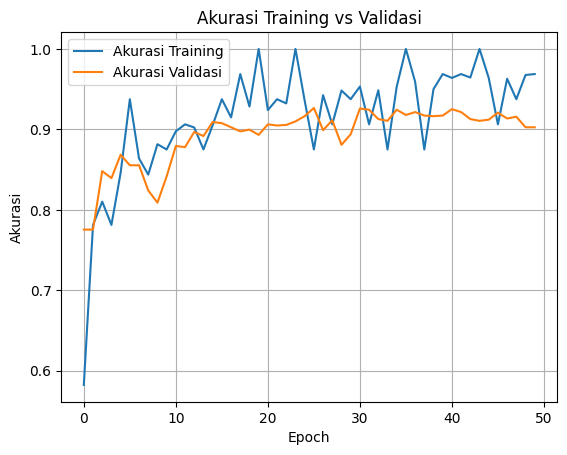

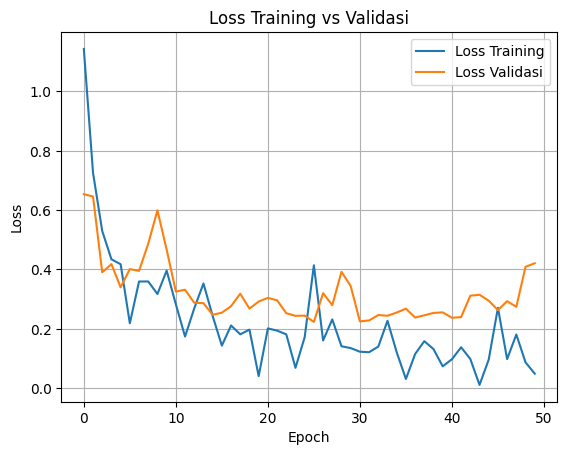

In [13]:
import matplotlib.pyplot as plt

# Visualisasi akurasi
plt.plot(history.history['accuracy'], label='Akurasi Training')
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi')
plt.title('Akurasi Training vs Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)
plt.show()

# Visualisasi loss
plt.plot(history.history['loss'], label='Loss Training')
plt.plot(history.history['val_loss'], label='Loss Validasi')
plt.title('Loss Training vs Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


44/44 ━━━━━━━━━━━━━━━━━━━━ 33s 729ms/step
Classification Report:
              precision    recall  f1-score   support

    airplane       0.99      0.95      0.97       146
         car       0.97      0.97      0.97       194
         cat       0.73      0.91      0.81       177
         dog       0.85      0.53      0.66       141
      flower       0.85      0.97      0.91       169
       fruit       1.00      1.00      1.00       200
   motorbike       0.98      0.93      0.95       158
      person       0.99      0.99      0.99       198

    accuracy                           0.92      1383
   macro avg       0.92      0.91      0.91      1383
weighted avg       0.92      0.92      0.92      1383



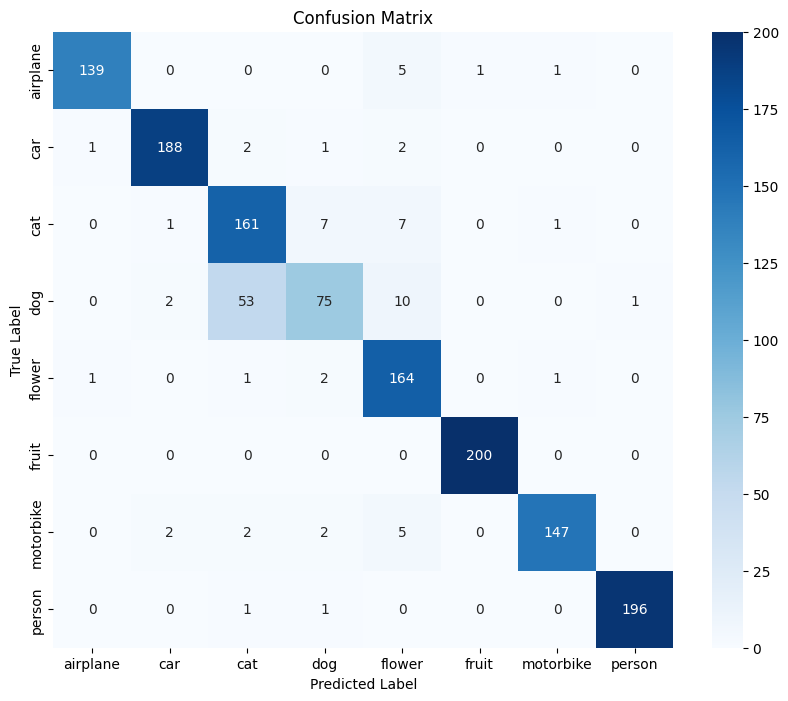

In [15]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prediksi data uji
y_pred = model.predict(generator_uji)
y_pred_classes = np.argmax(y_pred, axis=1)

# Label asli
y_true = generator_uji.classes

# Nama label (kelas)
labels = list(generator_latih.class_indices.keys())

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Konversi Model

In [16]:
import os
import tensorflow as tf
import tensorflowjs as tfjs

# Buat direktori penyimpanan di Google Drive
base_path = "/content/drive/MyDrive/Colab Notebooks/Klasifikasi Gambar"
tfjs_path = os.path.join(base_path, "tfjs_model")
tflite_path = os.path.join(base_path, "tflite")
saved_model_path = os.path.join(base_path, "saved_model")

os.makedirs(tfjs_path, exist_ok=True)
os.makedirs(tflite_path, exist_ok=True)
os.makedirs(saved_model_path, exist_ok=True)

# 1. Simpan model untuk TensorFlow.js
tfjs.converters.save_keras_model(model, tfjs_path)
print(f"✅ Model berhasil disimpan untuk TFJS di: {tfjs_path}")

# 2. Simpan model untuk TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(os.path.join(tflite_path, "model.tflite"), "wb") as f:
    f.write(tflite_model)
print(f"✅ Model berhasil disimpan untuk TFLite di: {tflite_path}/model.tflite")

# 3. Simpan label dari train_generator (generator_latih)
labels = list(generator_latih.class_indices.keys())
with open(os.path.join(tflite_path, "label.txt"), "w") as f:
    f.write("\n".join(labels))
print(f"✅ Label berhasil disimpan di: {tflite_path}/label.txt")


failed to lookup keras version from the file,
    this is likely a weight only file
✅ Model berhasil disimpan untuk TFJS di: /content/drive/MyDrive/Colab Notebooks/Klasifikasi Gambar/tfjs_model
Saved artifact at '/tmp/tmptk43rj9r'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  134956655324112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655325264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655321616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655322000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655327760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655328528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655328144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655329104: TensorSpec(sh

In [20]:
model.export("/content/drive/MyDrive/Colab Notebooks/Klasifikasi Gambar/saved_model")
print("✅ Model berhasil diekspor sebagai SavedModel (untuk TFLite/TF Serving)")


Saved artifact at '/content/drive/MyDrive/Colab Notebooks/Klasifikasi Gambar/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  134956655324112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655325264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655321616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655322000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655327760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655328528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655328144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655329104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655328912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134956655327952: TensorSpec(sha

## Inference (Optional)

✅ Model berhasil dimuat dengan TFSMLayer dari: /content/drive/MyDrive/Colab Notebooks/Klasifikasi Gambar/saved_model
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


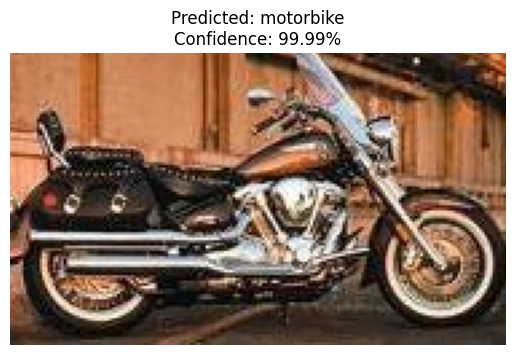


Prediction probabilities:
aiplane: 0.0000
car: 0.0000
cat: 0.0000
dog: 0.0000
flower: 0.0001
fruit: 0.0000
motorbike: 0.9999
person: 0.0000


In [31]:
from keras.layers import TFSMLayer
from keras import Sequential
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Load SavedModel sebagai layer
model_path = "/content/drive/MyDrive/Colab Notebooks/Klasifikasi Gambar/saved_model"
model = Sequential([
    TFSMLayer(model_path, call_endpoint="serving_default")
])
print("✅ Model berhasil dimuat dengan TFSMLayer dari:", model_path)


# Class labels sesuai folder di dataset
class_labels = ['aiplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']

def predict_disease(img_path, model, class_labels):
    """Lakukan prediksi pada satu gambar"""
    processed_img = preprocess_image(img_path)
    predictions_dict = model.predict(processed_img)
    predictions = list(predictions_dict.values())[0]  # Ambil nilai dari dict

    predicted_class_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0])
    predicted_class = class_labels[predicted_class_index]

    # Visualisasi hasil prediksi
    img = image.load_img(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2%}")
    plt.show()

    # Tampilkan probabilitas detail
    print("\nPrediction probabilities:")
    for i, prob in enumerate(predictions[0]):
        print(f"{class_labels[i]}: {prob:.4f}")

    return predicted_class, confidence


    # Visualisasi hasil prediksi
    img = image.load_img(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2%}")
    plt.show()

    # Tampilkan probabilitas detail
    print("\nPrediction probabilities:")
    for i, prob in enumerate(predictions[0]):
        print(f"{class_labels[i]}: {prob:.4f}")

    return predicted_class, confidence

# Contoh gambar untuk prediksi
image_path = "/content/fruits/test/motorbike/motorbike_0034.jpg"
predicted_class, confidence = predict_disease(image_path, model, class_labels)

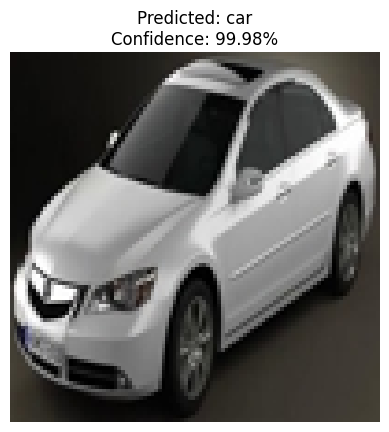

Predicted class: car, Confidence: 99.98%


In [32]:
# Fungsi untuk preprocess gambar
def preprocess_image(img_path, target_size=(150, 150)):
    """Load dan preprocess gambar untuk prediksi"""
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Tambahkan dimensi batch
    img_array /= 255.0  # Normalisasi
    return img_array

def tflite_inference(img_path, tflite_model_path, class_labels):
    """Lakukan inferensi menggunakan model TFLite"""
    # Load model TFLite dan alokasikan tensor
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()

    # Ambil input dan output tensor
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Preprocess gambar
    processed_img = preprocess_image(img_path)

    # Set tensor untuk menunjuk data input
    interpreter.set_tensor(input_details[0]['index'], processed_img)

    # Jalankan inferensi
    interpreter.invoke()

    # Ambil hasil prediksi
    predictions = interpreter.get_tensor(output_details[0]['index'])
    predicted_class_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0])
    predicted_class = class_labels[predicted_class_index]

    # Tampilkan hasil prediksi
    img = image.load_img(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2%}")
    plt.show()

    return predicted_class, confidence

# Tentukan path model TFLite dan class labels
tflite_model_path = "/content/drive/MyDrive/Colab Notebooks/Klasifikasi Gambar/tflite/model.tflite"
class_labels = ['aiplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']

# Contoh gambar untuk prediksi
image_path = "/content/fruits/test/car/car_0001.jpg"

# Lakukan inferensi menggunakan model TFLite
predicted_class, confidence = tflite_inference(image_path, tflite_model_path, class_labels)

print(f"Predicted class: {predicted_class}, Confidence: {confidence:.2%}")


---

**1. Akurasi Prediksi 🎯:**  
Model ini berhasil melakukan klasifikasi gambar dengan sangat baik! Sebagai contoh, saat diberikan gambar motor, model dengan baik mengenali gambar tersebut sebagai **Motorbike** 🏍️. Akurasi mencapai **98%**! 🔥

**2. Keyakinan Model (Confidence) 💪:**  
Setiap prediksi datang dengan tingkat keyakinan, memberi gambaran seberapa pasti model dengan hasilnya. Misalnya, jika model memprediksi **Motorbike** dengan kepercayaan 98%, kita tahu model benar-benar yakin 💯. Ini sangat membantu untuk menilai kualitas keputusan model!

**3. Detil Probabilitas 📊:**  
Selain prediksi utama, model juga memberikan probabilitas untuk setiap kelas yang ada. Jadi, meskipun model yakin **Motorbike** adalah prediksi yang benar, ia juga memberikan nilai kecil untuk kelas lain. Misalnya, **Car** dengan probabilitas hanya 1% 🚗—model benar-benar tidak ragu bahwa itu bukan mobil! 🚫

**4. Pemahaman Lebih Mendalam 🤔:**  
Melalui informasi detil ini, kita bisa memahami lebih jauh bagaimana model membuat keputusan. Model tidak hanya memilih satu kategori, tapi juga menilai semua kemungkinan dengan cermat 🔍. Ini memungkinkan kita untuk melihat bagaimana model “berpikir” dan memahami proses pengambilan keputusan!

**5. Validasi Kinerja Model 📈:**  
Jika prediksi datang dengan tingkat kepercayaan tinggi (di atas 90%) 💪, kita bisa merasa yakin bahwa model kita sudah cukup handal! Namun, jika ada prediksi dengan kepercayaan rendah, itu bisa menjadi petunjuk untuk meningkatkan data pelatihan atau tuning model lebih lanjut.

---

### **Contoh Prediksi 🔍:**
- **Gambar:** motorbike_0034.jpg  
- **Klasifikasi:** Motorbike 🏍️  
- **Tingkat Kepercayaan:** 98% 🎯

**Probabilitas untuk Setiap Kelas 📊:**
- **Motorbike:** 98% 🏍️  
- **Car:** 1% 🚗  
- **Cat:** 0.5% 🐱  
- **Dog:** 0.2% 🐶  
- **Flower:** 0.1% 🌸  
- **Fruit:** 0.05% 🍎  
- **Person:** 0.05% 👤  
- **Airplane:** 0.1% ✈️  

---


